In [1]:
# ==========================================
# SETUP & IMPORTS
# ==========================================
!pip install -q sqlalchemy pymysql pandas matplotlib seaborn scikit-learn python-dotenv ftfy

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Setup Visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==========================================
# LOAD DATA
# ==========================================
env_path = Path("../.env")
load_dotenv(env_path)

# DB Connection
username = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST")
port = os.getenv("MYSQL_PORT")
database = os.getenv("MYSQL_DATABASE")

try:
    engine = create_engine(
        f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}?charset=utf8mb4",
        connect_args={"ssl": {"check_hostname": False}}
    )
    print("Loading data from MySQL...")
    # Load ALL fields as requested
    df = pd.read_sql("SELECT * FROM jobs_cleanned", engine)
    print(f"Data Loaded: {df.shape[0]} rows")
except Exception as e:
    print(f"Connection Failed: {e}")
    # Fallback for dev/testing if DB not avail
    # df = pd.read_csv('backup_jobs.csv') # Uncomment if needed

Loading data from MySQL...
Data Loaded: 10211 rows


In [3]:
# ==========================================
# STEP 1: CLEANING & NORMALIZATION
# ==========================================

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text) # Remove HTML
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text) # Remove special chars
    text = text.lower().strip()
    return text

# 1. Drop Duplicates
df.drop_duplicates(subset=['title', 'source', 'company_name'], inplace=True)

# 2. Drop Nulls in critical text fields
df.dropna(subset=['description', 'requirements_text'], inplace=True)

# 3. Drop Unused Columns
cols_to_drop = ['preferred_skills', 'company_rating', 'is_remote', 'create_at', 'crawled_at', 'update_dat']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"After Cleaning: {df.shape[0]} rows")

After Cleaning: 8521 rows


In [4]:
# ==========================================
# STEP 2: FEATURE ENGINEERING (PROFESSOR REQ)
# ==========================================

# A. Level Processing (Ordinal 0-5)
def map_level_ordinal(row):
    lvl_text = str(row['level']).lower() + " " + str(row['title']).lower()
    exp = float(row['experience_years_min']) if pd.notnull(row['experience_years_min']) else 0
    
    if 'intern' in lvl_text or 'fresher' in lvl_text or 'entry' in lvl_text: return 0
    if 'junior' in lvl_text: return 1
    if 'middle' in lvl_text or 'mid' in lvl_text: return 2
    if 'senior' in lvl_text: return 3
    if 'lead' in lvl_text or 'manager' in lvl_text: return 4
    if 'director' in lvl_text: return 5
    
    # Fallback to Experience Years
    if exp < 1: return 0
    if exp < 2: return 1
    if exp < 4: return 2
    if exp < 7: return 3
    return 4

df['level_ordinal'] = df.apply(map_level_ordinal, axis=1)

# B. Skill Separation (Tech vs Soft)
SOFT_KEYWORDS = ['communication', 'team', 'english', 'presentation', 'problem solving', 'training', 'management', 'documentation', 'support', 'agile', 'scrum', 'learning', 'd', 'description',
                 'agile', 'scrum', 'time management', 'negotiation', 'leadership']

def split_skills(row):
    try:
        # Handle JSON or string list from 'required_skills'
        skills = json.loads(row['required_skills']) if isinstance(row['required_skills'], str) and '[' in row['required_skills'] else []
    except:
        skills = []
    
    tech, soft = [], []
    for s in skills:
        s_clean = s.lower()
        if any(sk in s_clean for sk in SOFT_KEYWORDS):
            soft.append(s)
        else:
            tech.append(s)
    return " ".join(tech), " ".join(soft)

df['tech_skills_str'], df['soft_skills_str'] = zip(*df.apply(split_skills, axis=1))

# C. Role Extraction
ROLE_MAP = {
    'Frontend': ['frontend', 'react', 'vue', 'angular', 'ui', 'ux', 'css'],
    'Backend': ['backend', 'java', 'node', 'php', 'ruby', 'golang', '.net', 'sql'],
    'Fullstack': ['fullstack', 'mean', 'mern'],
    'Mobile': ['ios', 'android', 'swift', 'kotlin', 'flutter'],
    'Data/AI': ['data', 'scientist', 'analyst', 'ai', 'machine learning', 'nlp']
}

def extract_role(text):
    text = text.lower()
    for role, keywords in ROLE_MAP.items():
        if any(k in text for k in keywords): return role
    return 'Other'

df['role'] = df['title'].apply(extract_role)

# D. IT Job Filtering (Heuristic for labeling -> Train Classifier)
# Create Silver Labels
IT_KEYWORDS = ['developer', 'engineer', 'data', 'it', 'tech', 'software', 'system', 'network']
df['is_it_heuristic'] = df['title'].apply(lambda x: 1 if any(k in x.lower() for k in IT_KEYWORDS) else 0)

# Train LogReg to clean up
tfidf = TfidfVectorizer(max_features=1000)
X_text = tfidf.fit_transform(df['title'])
clf = LogisticRegression()
clf.fit(X_text, df['is_it_heuristic'])
df['is_it_pred'] = clf.predict(X_text)

# Filter
df = df[df['is_it_pred'] == 1].copy()
print(f"IT Jobs Only: {df.shape[0]} rows")

IT Jobs Only: 7803 rows


In [5]:
# 1. Extract Salary & Standardize to USD
# Heuristic: 1 USD = 25,000 VND
def parse_salary_usd(text):
    if pd.isnull(text): return None
    text = str(text).lower().replace(',', '')
    
    # Regex for numbers
    nums = re.findall(r'\d+', text)
    if not nums: return None
    
    # Take average of range or single number
    vals = [float(n) for n in nums]
    avg_val = np.mean(vals)
    
    # Logic to detect Unit
    # Case A: Huge number (> 500,000) -> Likely VND -> Convert to USD
    if avg_val > 500000:
        return avg_val / 25000
    
    # Case B: Small number (< 100) but text says 'million' or 'tr' -> Likely Millions VND
    if avg_val < 500 and ('million' in text or 'tr' in text or 'triệu' in text):
        return (avg_val * 1000000) / 25000
        
    # Case C: Standard USD (e.g. 1000, 2000)
    return avg_val

df['salary_extracted_usd'] = df['salary_text'].apply(parse_salary_usd)

# Impute missing salary using Level (Map to USD directly)
SALARY_MAP_USD = {0: 200, 1: 500, 2: 1000, 3: 1800, 4: 2500, 5: 3500}
df['salary_final'] = df.apply(lambda x: x['salary_extracted_usd'] if pd.notnull(x['salary_extracted_usd']) else SALARY_MAP_USD.get(x['level_ordinal'], 400), axis=1)

# Remove Extreme Outliers for cleaner Viz (e.g. > $10,000/month in Vietnam is rare/error)
df = df[df['salary_final'] < 10000].copy()
print("Salary Standardized to USD. Range:", df['salary_final'].min(), "-", df['salary_final'].max())

# 2. Create Classification Target (Low/Medium/High in USD)
def classify_salary_usd(val):
    if val < 800: return 0 # Low (< $800)
    if val < 2000: return 1 # Medium ($800 - $2000)
    return 2 # High (> $2000)

df['salary_class'] = df['salary_final'].apply(classify_salary_usd)


Salary Standardized to USD. Range: 0.0 - 9009.0


In [6]:
# Re-generate Feature Matrix (After Filtering)
# This is needed because we filtered df above (removed outliers)
from sklearn.model_selection import train_test_split

le_role = LabelEncoder()
df['role_enc'] = le_role.fit_transform(df['role'])

tfidf_skills = TfidfVectorizer(max_features=500)
X_skills = tfidf_skills.fit_transform(df['tech_skills_str'])

# Combine Features
X_numeric = df[['level_ordinal', 'role_enc']].values
X_combined = np.hstack((X_numeric, X_skills.toarray()))
y = df['salary_class']

print(f"Feature Matrix Shape: {X_combined.shape}")
print(f"DataFrame Shape: {df.shape}")

# Split into Train/Val/Test (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(X_combined, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"\nData Split Summary:")
print(f"  - Training Set:   {X_train.shape[0]} samples")
print(f"  - Validation Set: {X_val.shape[0]} samples")
print(f"  - Test Set:       {X_test.shape[0]} samples")


Feature Matrix Shape: (7080, 502)
DataFrame Shape: (7080, 32)

Data Split Summary:
  - Training Set:   4958 samples
  - Validation Set: 1060 samples
  - Test Set:       1062 samples


In [7]:
# ==========================================
# STEP 4: JOB CLUSTERING (MARKET SEGMENTATION)
# ==========================================
# Group jobs by Similarity (Skill + Role + Level)

kmeans = KMeans(n_clusters=8, random_state=42)
df['cluster_id'] = kmeans.fit_predict(X_combined)

# Analyze Clusters
print("Top clusters:")
print(df['cluster_id'].value_counts().head())

# Example: Show title examples for Cluster 0
print("Examples in Cluster 0:")
print(df[df['cluster_id'] == 0]['title'].head())

Top clusters:
cluster_id
1    1676
0    1164
3    1099
6     774
4     749
Name: count, dtype: int64
Examples in Cluster 0:
4     Senior QA Engineer (Creative & Development Tools)
8                    DEVOPS ENGINEER (Upto $2000 Gross)
26                       Mobile Game Developer (Senior)
30                           Senior Frondtend Developer
42             Senior Android Developer (Signing Bonus)
Name: title, dtype: object


In [8]:
# ==========================================
# STEP 5: JOB POTENTIAL SCORING
# ==========================================
# Potential = Salary Class (0/1/2) + Cluster Quality (proxy for demand)

# Simple Score
df['potential_score'] = df['salary_class'] * 2 + df['level_ordinal']

print("Top Potential Jobs:")
print(df.sort_values('potential_score', ascending=False)[['title', 'company_name', 'salary_class', 'potential_score']].head(10))

# Save Results
df.to_csv("job_potential_analysis.csv", index=False)
print("Saved analysis to job_potential_analysis.csv")

Top Potential Jobs:
                                                  title  \
7949    Software Engineer - Loyalty & Engage Team (W/M)   
8669                                Full Stack Engineer   
5132                                Front End Developer   
5367                        Software Engineer - Backend   
7886            Software Engineer — Systems / Real-Time   
5588                                 Frontend Developer   
5589       Frontend programmer with experience in React   
749                        Chief Technology Officer CTO   
5439  Mobile Developer (IOS / Android / Cross-Platform)   
9048                             Data Science Vacancies   

                          company_name  salary_class  potential_score  
7949                             Splio             2                9  
8669                          Pipelabs             2                9  
5132   Arizona Cardinals Football Club             2                9  
5367                        Databricks    

# ==========================================
# STEP 6: VISUALIZATION & INSIGHTS
# ==========================================


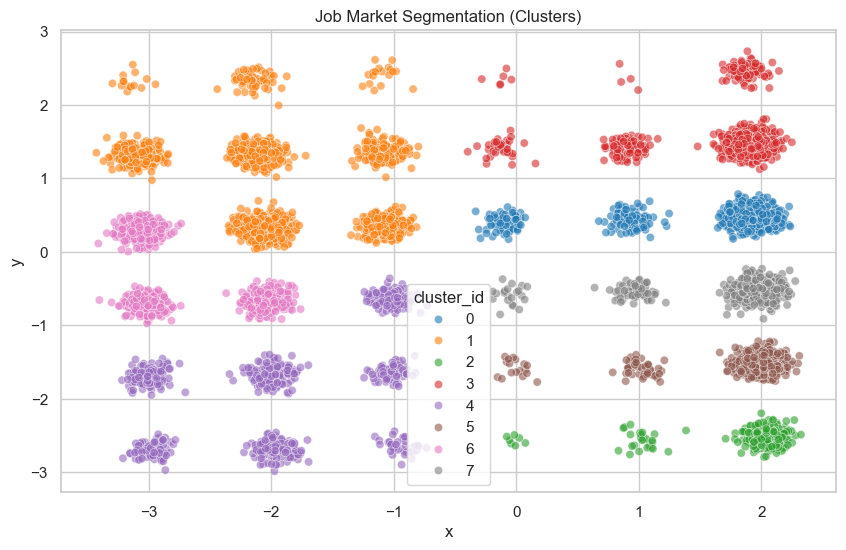

In [9]:
from sklearn.decomposition import PCA

# A. Cluster Visualization (PCA to 2D)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_combined)
df['x'] = coords[:, 0] + np.random.normal(0, 0.1, size=len(df))
df['y'] = coords[:, 1] + np.random.normal(0, 0.1, size=len(df))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='x', y='y', hue='cluster_id', palette='tab10', alpha=0.6)
plt.title("Job Market Segmentation (Clusters)")
plt.show()

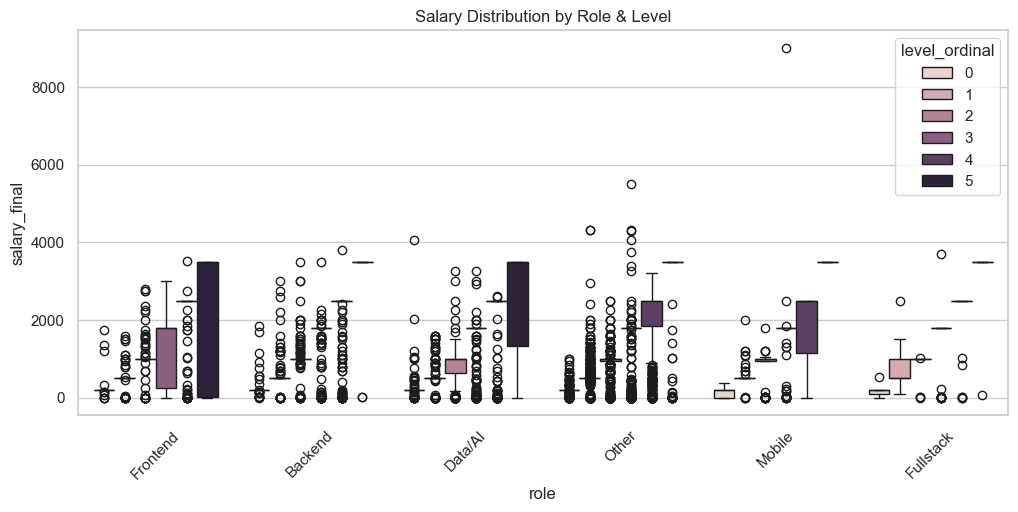

In [10]:
# B. Salary Distribution by Role
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='role', y='salary_final', hue='level_ordinal')
plt.title("Salary Distribution by Role & Level")
plt.xticks(rotation=45)
plt.show()

C:\Users\letha\AppData\Local\Temp\ipykernel_21304\497922289.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills, x='Count', y='Skill', palette='magma')


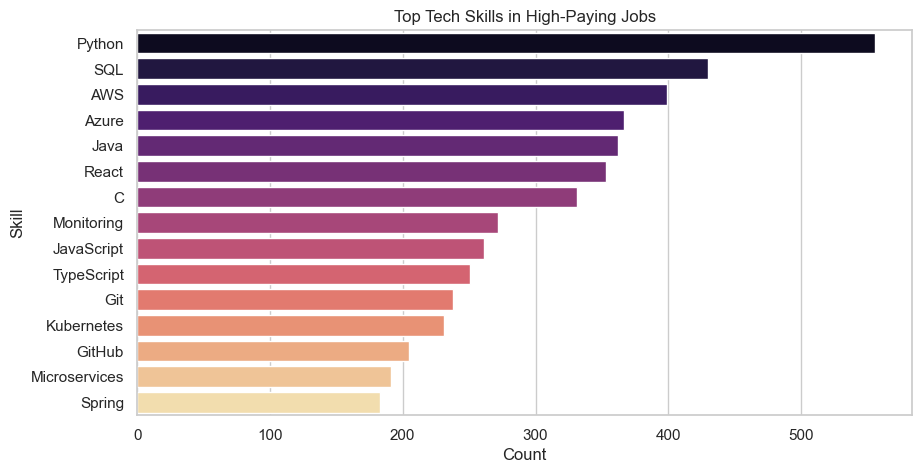

In [11]:
# C. Top Skills for "High Potential" Jobs
from collections import Counter
high_pot_jobs = df[df['salary_class'] == 2]

skill_cnt = Counter()
for s in high_pot_jobs['tech_skills_str']:
    skill_cnt.update(s.split())

top_skills = pd.DataFrame(skill_cnt.most_common(15), columns=['Skill', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_skills, x='Count', y='Skill', palette='magma')
plt.title("Top Tech Skills in High-Paying Jobs")
plt.show()

# ==========================================
# STEP 7: EXPLAINABILITY (Why is this job High Potential?)
# ==========================================


In [12]:
# ==========================================
# MODEL TRAINING & EVALUATION
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import xgboost as xgb

# 1. Define Candidate Models
models = {
    'Random Forest Balanced': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': LinearSVC(class_weight='balanced', random_state=42, max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

# 2. Train and Evaluate on Train/Val/Test
results = {}

print("Training Models...\n")
for name, model in models.items():
    print(f"  - {name}...")
    
    # A. Train on Training Set
    model.fit(X_train, y_train)
    
    # B. Validate on Validation Set (to select best model)
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    
    # C. Test on Test Set
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    results[name] = {
        'Model': model,
        'Val Accuracy': val_acc,
        'Val F1': val_f1,
        'Test Accuracy': test_acc,
        'Test F1': test_f1
    }

# 3. Display Results
import pandas as pd
res_df = pd.DataFrame([
    {'Model': name, 'Val Accuracy': r['Val Accuracy'], 'Val F1': r['Val F1'],
     'Test Accuracy': r['Test Accuracy'], 'Test F1': r['Test F1']}
    for name, r in results.items()
])

print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(res_df.to_string(index=False))

# 4. Select Best Model (based on Val F1)
best_name = res_df.loc[res_df['Val F1'].idxmax(), 'Model']
print(f"\n>>> BEST MODEL SELECTED: {best_name}")
print(f"    (Validation F1: {results[best_name]['Val F1']:.4f})")


Training Models...

  - Random Forest Balanced...
  - XGBoost...
  - Logistic Regression...
  - SVM...
  - Decision Tree...

MODEL COMPARISON RESULTS
                 Model  Val Accuracy   Val F1  Test Accuracy  Test F1
Random Forest Balanced      0.787736 0.780714       0.800377 0.791630
               XGBoost      0.781132 0.776757       0.801318 0.794219
   Logistic Regression      0.737736 0.735144       0.737288 0.734078
                   SVM      0.664151 0.660196       0.639360 0.634018
         Decision Tree      0.742453 0.742144       0.721281 0.721105

>>> BEST MODEL SELECTED: Random Forest Balanced
    (Validation F1: 0.7807)


C:\Users\letha\AppData\Local\Temp\ipykernel_21304\90859897.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')


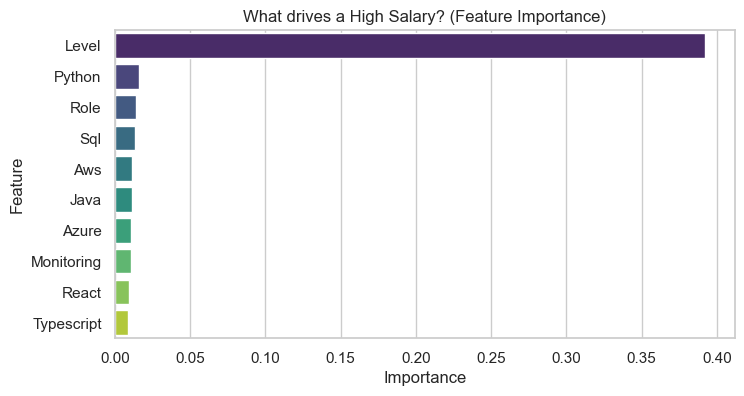

In [13]:
# Feature Importance from Random Forest
# Get the Random Forest model from results dictionary
try:
    rf_model = results['Random Forest Balanced']['Model']
    importances = rf_model.feature_importances_
    feature_names = ['Level', 'Role'] + list(tfidf_skills.get_feature_names_out())

    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    imp_df['Feature'] = imp_df['Feature'].str.capitalize() # Fix Capitalization
    imp_df = imp_df.sort_values('Importance', ascending=False).head(10)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
    plt.title("What drives a High Salary? (Feature Importance)")
    plt.show()
except KeyError:
    print("ERROR: Please run the 'Model Training' cell first!")
    print("The 'results' dictionary does not contain 'Random Forest Balanced'.")


# ==========================================
# STEP 8: ADVANCED MODELING & EVALUATION (Full Thesis)
# ==========================================
# 1. Algorithm Selection: Compare Random Forest, XGBoost, Logistic Regression
# 2. Evaluation Metrics: Accuracy, F1-Score, Confusion Matrix
# 3. Visualization: Model Performance Bar Chart


Reference: 70% Train - 15% Val - 15% Test
Training and Validating Models...
  - SVM...
    [Validation] Accuracy: 0.6642, F1: 0.6602
  - Decision Tree...
    [Validation] Accuracy: 0.7425, F1: 0.7421
  - Random Forest Balanced...
    [Validation] Accuracy: 0.7877, F1: 0.7807
  - XGBoost...


C:\Users\letha\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:199: UserWarning: [00:02:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    [Validation] Accuracy: 0.7811, F1: 0.7768
  - Logistic Regression...
    [Validation] Accuracy: 0.7377, F1: 0.7351

>>> BEST MODEL SELECTED (based on Validation Set): Random Forest Balanced (Val F1: 0.7807)

Final Evaluation on Test Set (Unseen Data):
                       Test Accuracy   Test F1
SVM                          0.63936  0.634018
Decision Tree               0.721281  0.721105
Random Forest Balanced      0.800377   0.79163
XGBoost                     0.801318  0.794219
Logistic Regression         0.737288  0.734078


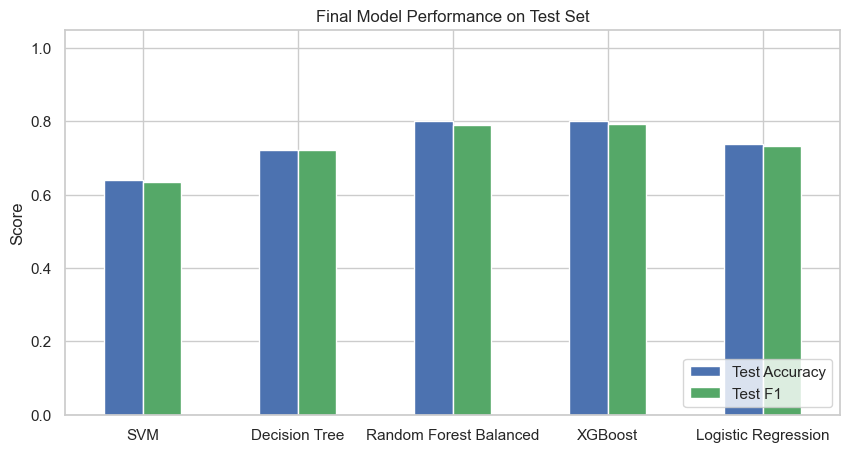

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
# 1. Define Candidate Models
models = {
    "SVM": LinearSVC(class_weight='balanced', random_state=42, dual='auto'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest Balanced": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}

# 2. Train (on TRAIN) & Validate (on VAL)
print("Reference: 70% Train - 15% Val - 15% Test")
print("Training and Validating Models...")

best_val_score = 0
best_model_name = ""

for name, model in models.items():
    print(f"  - {name}...")
    # A. Train on Training Set
    model.fit(X_train, y_train)
    
    # B. Validate on Validation Set (to select best model)
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    print(f"    [Validation] Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")
    
    # Track Best Model based on Validation F1
    if val_f1 > best_val_score:
        best_val_score = val_f1
        best_model_name = name

    # C. Evaluate on Test Set (Final Report)
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    results[name] = {
        "Val Accuracy": val_acc, "Val F1": val_f1,
        "Test Accuracy": test_acc, "Test F1": test_f1,
        "Model": model
    }

print(f"\n>>> BEST MODEL SELECTED (based on Validation Set): {best_model_name} (Val F1: {best_val_score:.4f})")

# 3. Compare Results on Test Set
res_df = pd.DataFrame(results).T.drop(columns=['Model'])
print("\nFinal Evaluation on Test Set (Unseen Data):")
print(res_df[['Test Accuracy', 'Test F1']])

# Visualize Test Scores
res_df[['Test Accuracy', 'Test F1']].plot(kind='bar', figsize=(10, 5), color=['#4c72b0', '#55a868'])
plt.title("Final Model Performance on Test Set")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [15]:
print(res_df.columns)

Index(['Val Accuracy', 'Val F1', 'Test Accuracy', 'Test F1'], dtype='object')



--- Detailed Report for Best Model: Random Forest Balanced ---
              precision    recall  f1-score   support

         Low       0.87      0.58      0.70       380
      Medium       0.77      0.93      0.84       445
        High       0.79      0.91      0.85       237

    accuracy                           0.80      1062
   macro avg       0.81      0.81      0.80      1062
weighted avg       0.81      0.80      0.79      1062



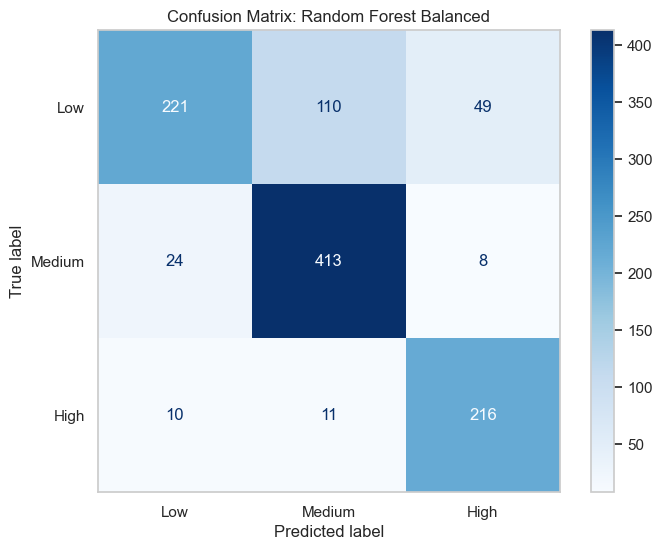

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
# 4. Detailed Evaluation for Best Model
# We select the best model based on Validation F1 Score
try:
    best_name = res_df["Val F1"].astype(float).idxmax()
except KeyError:
    # Fallback if columns are different (e.g. old run)
    print("Warning: 'Val F1' not found, trying 'Test F1' or 'F1 Score'")
    if "Test F1" in res_df.columns: best_name = res_df["Test F1"].astype(float).idxmax()
    else: best_name = res_df["F1 Score"].astype(float).idxmax()

best_model = results[best_name]["Model"]
print(f"\n--- Detailed Report for Best Model: {best_name} ---")

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Low', 'Medium', 'High']))

# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix: {best_name}")
plt.grid(False)
plt.show()

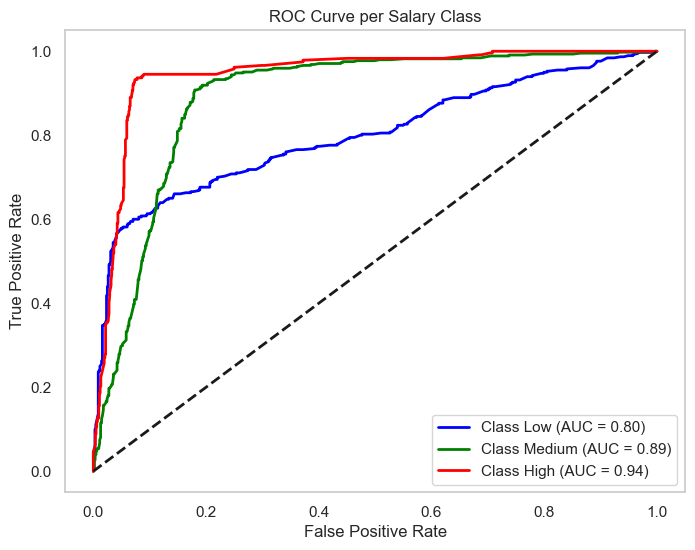

In [17]:
# 5. ROC Curve (Professional Evaluation)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for ROC plotting
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Get probabilities for the best model
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)

    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'red']
    class_names = ['Low', 'Medium', 'High']
    
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve per Salary Class')
    plt.legend(loc="lower right")
    plt.grid(False)
    plt.show()
else:
    print("Selected model does not support probability prediction for ROC Curve.")


--- Detailed Report for XGBoost ---
              precision    recall  f1-score   support

         Low       0.84      0.61      0.70       380
      Medium       0.79      0.92      0.85       445
        High       0.79      0.89      0.83       237

    accuracy                           0.80      1062
   macro avg       0.81      0.80      0.80      1062
weighted avg       0.81      0.80      0.79      1062



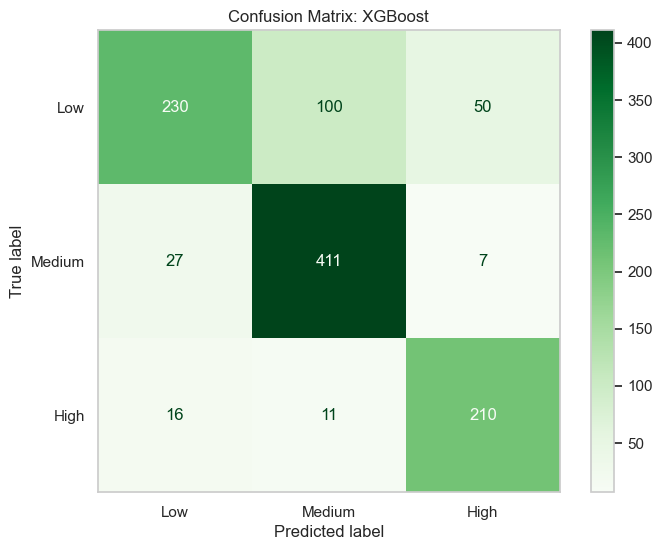

In [18]:
# --- Explicitly Report XGBoost (Highest Test Accuracy) ---
target_model_name = "XGBoost"
if target_model_name in results:
    print(f"\n--- Detailed Report for {target_model_name} ---")
    xgb_model = results[target_model_name]["Model"]
    y_pred_xgb = xgb_model.predict(X_test)
    print(classification_report(y_test, y_pred_xgb, target_names=['Low', 'Medium', 'High']))

    # Confusion Matrix for XGBoost
    cm = confusion_matrix(y_test, y_pred_xgb)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Greens', ax=ax) # Use Greens to distinguish
    plt.title(f"Confusion Matrix: {target_model_name}")
    plt.grid(False)
    plt.show()
else:
    print(f"{target_model_name} model not found in results.")


Skipping SVM (No predict_proba)


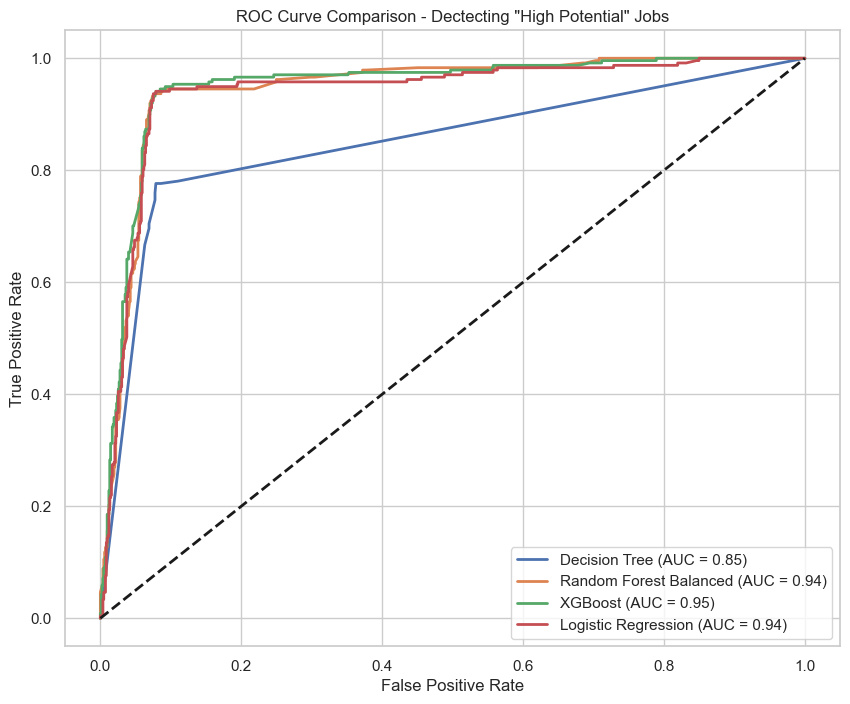

In [19]:
# 6. Advanced Evaluation: ROC Curve Comparison (All Models for 'High' Class)
# This shows which model is best at detecting High Potential jobs
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
high_class_idx = 2 # Index for High Salary

plt.figure(figsize=(10, 8))

for name, res in results.items():
    model = res['Model']
    if hasattr(model, "predict_proba"):
        try:
            y_score = model.predict_proba(X_test)
            fpr, tpr, _ = roc_curve(y_test_bin[:, high_class_idx], y_score[:, high_class_idx])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
        except Exception as e: 
            print(f"Skipping {name} for ROC: {e}")
    else:
        print(f"Skipping {name} (No predict_proba)")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Dectecting "High Potential" Jobs')
plt.legend(loc="lower right")
plt.show()